In [5]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.image as img
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
path = '/n/archive/labs/hsi-data/everyday_objects/kitchen/'

folder_name1 = 'basmatiriisi'
file_number1 = '040'

folder_name2 = 'kuivahiiva'
file_number2 = '042'

folder_name3 = 'seesaminsiemen'
file_number3 = '044'

In [3]:
def retrieve_picture(path, folder_name, file_number):
    data = envi.open(path+folder_name+'/capture/'+file_number)
    data_white = envi.open(path+folder_name+'/capture/WHITEREF_'+file_number)
    data_dark = envi.open(path+folder_name+'/capture/DARKREF_'+file_number)
    return data, data_white, data_dark

def references(path, folder_name, file_number):
    dark_ref = envi.open(path+folder_name+'/capture/DARKREF_'+file_number+'.hdr', path+folder_name+'/capture/DARKREF_'+file_number+'.raw')
    white_ref = envi.open(path+folder_name+'/capture/WHITEREF_'+file_number+'.hdr', path+folder_name+'/capture/WHITEREF_'+file_number+'.raw')
    data_ref = envi.open(path+folder_name+'/capture/'+file_number+'.hdr', path+folder_name+'/capture/'+file_number+'.raw')
    return data_ref, white_ref, dark_ref

def nparr(path, folder_name, file_number):
    data_ref, white_ref, dark_ref = references(path, folder_name, file_number)

    white_nparr = np.array(white_ref.load())
    dark_nparr = np.array(dark_ref.load())
    data_nparr = np.array(data_ref.load())

    corrected_nparr = np.divide(
    np.subtract(data_nparr, dark_nparr),
    np.subtract(white_nparr, dark_nparr))
    return corrected_nparr

def squeeze(x, y, path, folder_name, file_number):
    corrected_nparr = nparr(path, folder_name, file_number)

    pixel = corrected_nparr[
    y:y+1,
    x:x+1,
    :]

    return np.squeeze(pixel)

ImageView object:
  Display bands       :  (100, 100, 100)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.02631578966975212), np.float64(0.9361382126808167)]
    G: [np.float64(0.02631578966975212), np.float64(0.9361382126808167)]
    B: [np.float64(0.02631578966975212), np.float64(0.9361382126808167)]

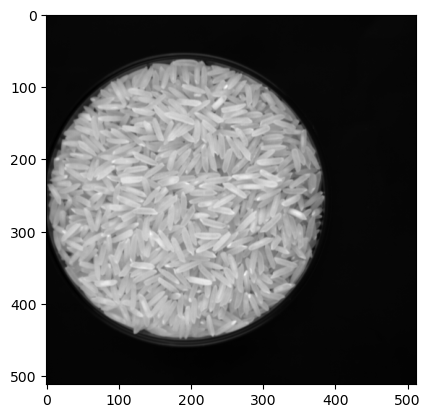

In [26]:
spectral.imshow(nparr(path, folder_name1, file_number1), (100, 100, 100))

# Pikselit voisi valita väliltä [150:350, 100:300]

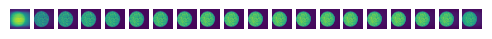

In [55]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 20

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')

plt.show()

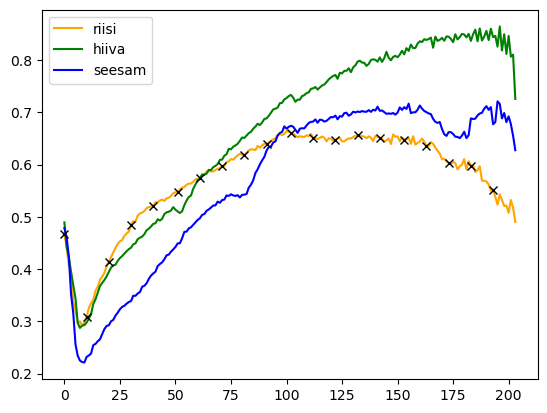

In [56]:
graphs = []

x = np.random.randint(150, 350)
y = np.random.randint(100, 300)

# Basmatiriisi
graphs.append(squeeze(x, y, path, folder_name1, file_number1))
#squeeze(200, 301, path, folder_name1, file_number1)
# Kuivahiiva
graphs.append(squeeze(x, y, path, folder_name2, file_number2))
#squeeze(200, 301, path, folder_name2, file_number2)
# Seesaminsiemen
graphs.append(squeeze(x, y, path, folder_name3, file_number3))
#squeeze(200, 301, path, folder_name3, file_number3)

plt.plot(np.arange(0,204), graphs[0], label = 'riisi', color='orange')
plt.plot(np.arange(0,204), graphs[1], label = 'hiiva', color='green')
plt.plot(np.arange(0,204), graphs[2], label = 'seesam', color='blue')
for p in range(0, i):
    plt.plot(int(p*(204/i)), graphs[0][int(p*(204/i))], marker='x', color='black')
plt.legend(loc='upper left')
plt.show()

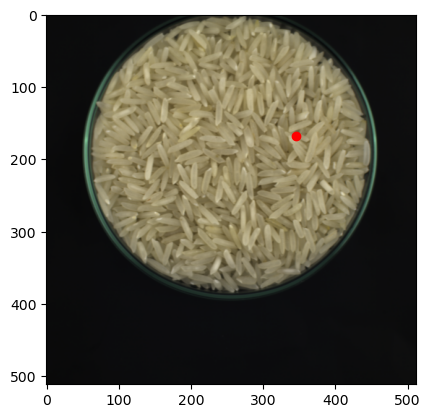

In [35]:
image = img.imread('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/040.png')
plt.plot(x, y, marker="o", color="red")
plt.imshow(image)

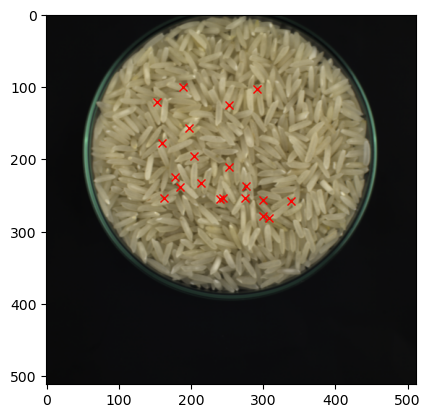

In [43]:
pixels = []
categories = []
coords = [[],[]]

for i in range(0, 20):
    x = np.random.randint(150, 350)
    y = np.random.randint(100, 300)
    pixels.append(squeeze(x, y, path, folder_name1, file_number1))
    categories.append("riisi")
    coords[0].append(x)
    coords[1].append(y)

for i in range(0, 20):
    pixels.append(squeeze(np.random.randint(150, 350), np.random.randint(100, 300), path, folder_name2, file_number2))
    categories.append("hiiva")

for i in range(0, 20):
    pixels.append(squeeze(np.random.randint(150, 350), np.random.randint(100, 300), path, folder_name3, file_number3))
    categories.append("seesam")

for i in range(0, 20):
    plt.plot(coords[0][i], coords[1][i], marker="x", color="red")

plt.imshow(image)

In [9]:
df = pd.DataFrame(pixels)
s = pd.Series(categories)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df, s, test_size=0.25, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)
y_pred
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 0.93


In [13]:
hdr = cv2.imread(path+folder_name1+'/capture/'+file_number1+'.hdr', flags=cv2.IMREAD_ANYDEPTH)

h = envi.read_envi_header(path+folder_name1+'/capture/'+file_number1+'.hdr')
print(h)
print(h['bands'])

{'description': 'Data recorded with Specim IQ', 'samples': '512', 'lines': '512', 'bands': '204', 'header offset': '0', 'file type': 'ENVI', 'data type': '12', 'interleave': 'BIL', 'sensor type': 'SPECIM IQ', 'byte order': '0', 'default bands': ['70', '53', '19'], 'latitude': '0.00000000', 'longitude': '0.00000000', 'acquisition date': '19-09-2024', 'errors': 'none', 'binning': ['1', '1'], 'tint': '31', 'fps': '32.2581', 'wavelength': ['397.32', '400.20', '403.09', '405.97', '408.85', '411.74', '414.63', '417.52', '420.40', '423.29', '426.19', '429.08', '431.97', '434.87', '437.76', '440.66', '443.56', '446.45', '449.35', '452.25', '455.16', '458.06', '460.96', '463.87', '466.77', '469.68', '472.59', '475.50', '478.41', '481.32', '484.23', '487.14', '490.06', '492.97', '495.89', '498.80', '501.72', '504.64', '507.56', '510.48', '513.40', '516.33', '519.25', '522.18', '525.10', '528.03', '530.96', '533.89', '536.82', '539.75', '542.68', '545.62', '548.55', '551.49', '554.43', '557.36', 